# Segmentation with SOPA

**Day 1 · Session 2.2**

Session 2.1 diagnosed the segmentation we were given. This one produces a different
segmentation and compares the two, because the useful question is never "is this
segmentation good" in the abstract — it is "is this one better than that one, for what I am
about to do".

[SOPA](https://gustaveroussy.github.io/sopa/) is the layer that makes this practical. It
reads a `SpatialData` object, runs a segmentation backend over it in patches, writes the
resulting boundaries back in, and aggregates transcripts onto them. It does not introduce a
new data model — everything stays in the object you already know.

### What you will be able to do afterwards

- Segment an image region with Cellpose through SOPA, and aggregate transcripts onto it
- Say why patch-based processing is what makes whole-slide segmentation tractable
- Choose between image-based and transcript-based backends for a given dataset
- Compare two segmentations quantitatively instead of by eye

## Setup

Segmentation is expensive, and this machine has no GPU. We therefore work on **one patch**
of the tissue, not the whole section — which is also how you should develop a segmentation
pipeline before committing a slide to it.

In [1]:
%matplotlib inline

import pathlib
import sys

# Find the repository root (the directory holding paths.py) and make it importable.
# Safe to re-run: unlike %cd, this does not move anywhere.
ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "paths.py").exists())
sys.path.insert(0, str(ROOT))

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import spatialdata as sd
import spatialdata_plot  # noqa: F401
import sopa

import paths

print("sopa", sopa.__version__)

sdata_full = sd.read_zarr(paths.data("xenium_breast_2fov.zarr"))
sdata_full

no parent found for <ome_zarr.reader.Label object at 0x1772e3cb0>: None


no parent found for <ome_zarr.reader.Label object at 0x177307ef0>: None


sopa 2.2.11


SpatialData object, with associated Zarr store: /opt/workshop/data/xenium_breast_2fov.zarr
├── Images
│     └── 'morphology_focus': DataTree[cyx] (4, 3529, 5792), (4, 1764, 2896), (4, 882, 1448), (4, 441, 724), (4, 220, 362)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (3529, 5792), (1764, 2896), (882, 1448), (441, 724), (220, 362)
│     └── 'nucleus_labels': DataTree[yx] (3529, 5792), (1764, 2896), (882, 1448), (441, 724), (220, 362)
├── Points
│     └── 'transcripts': DataFrame with shape: (1113950, 11) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (7275, 1) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (7312, 2) (2D shapes)
└── Tables
      └── 'table': AnnData (7275, 280)
with coordinate systems:
    ▸ 'global', with elements:
        morphology_focus (Images), cell_labels (Labels), nucleus_labels (Labels), transcripts (Points), cell_boundaries (Shapes), nucleus_boundaries (Shapes)

## 1. Take a patch

A 1000 x 1000 pixel window, about 210 um on a side. Small enough to segment live, large
enough to contain a few hundred cells and at least one interesting boundary region.

We write the crop into **your** output directory, because SOPA adds elements to the object
as it goes and the shared data directory is read-only.

In [3]:
sdata = sdata_full.query.bounding_box(
    axes=("x", "y"),
    min_coordinate=[2000, 1200],
    max_coordinate=[3000, 2200],
    target_coordinate_system="global",
)

patch_path = paths.OUT / "sopa_patch.zarr"
sdata.write(patch_path, overwrite=True)
sdata = sd.read_zarr(patch_path)

print(f"{sdata['table'].n_obs} vendor cells, {len(sdata['transcripts'])} transcripts in the patch")

/home/user1/2026_09_workshop_physalia/.pixi/envs/default/lib/python3.12/site-packages/dask/utils.py:782: UserWarning: Could not serialize pd.DataFrame.attrs: Object of type Scale is not JSON serializable, defaulting to empty attributes.
  return meth(arg, *args, **kwargs)
/home/user1/2026_09_workshop_physalia/.pixi/envs/default/lib/python3.12/site-packages/dask/dataframe/io/parquet/arrow.py:824: UserWarning: Could not serialize pd.DataFrame.attrs: Object of type Scale is not JSON serializable, defaulting to empty attributes.
  t = cls._pandas_to_arrow_table(df, preserve_index=preserve_index, schema=schema)


no parent found for <ome_zarr.reader.Label object at 0x31cfaee10>: None


no parent found for <ome_zarr.reader.Label object at 0x33116ed80>: None


455 vendor cells, 72491 transcripts in the patch


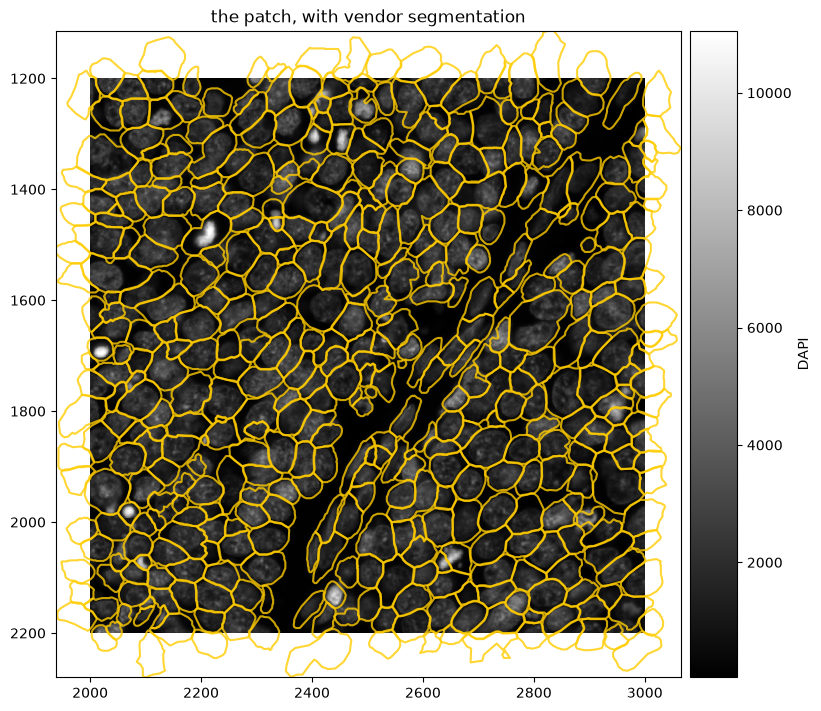

In [4]:
(
    sdata.pl.render_images("morphology_focus", channel="DAPI", cmap="gray")
    .pl.render_shapes("cell_boundaries", fill_alpha=0, outline_alpha=0.8, outline_color="#ffcc00")
    .pl.show(coordinate_systems="global", title="the patch, with vendor segmentation", figsize=(7, 7))
)

## 2. What the segmentation model actually sees

Cellpose takes an image, not a `SpatialData` object. Before handing it over, look at the
channel you are about to segment on — most segmentation failures are visible here, before
anything runs.

(1000, 1000)


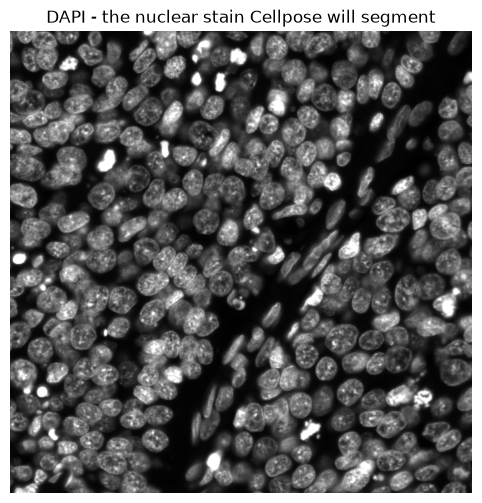

In [5]:
dapi = sdata["morphology_focus"]["scale0"]["image"].sel(c="DAPI")
print(dapi.shape)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(dapi.to_numpy(), cmap="gray", vmax=np.percentile(dapi.to_numpy(), 99))
ax.set_title("DAPI - the nuclear stain Cellpose will segment")
ax.axis("off")
plt.show()

> **_Question:_** This is a nuclear stain. What will a nucleus-only segmentation systematically
> miss, and how does that show up in the metrics from the previous notebook?

## 3. Patches

SOPA never segments a whole slide in one call. It tiles the image, segments each tile, and
then resolves conflicts where cells were cut by a tile border — which is what `patch_overlap`
is for. This is the mechanism that makes whole-slide segmentation tractable at all: the tiles
are independent, so they parallelise, and memory stays bounded no matter how large the slide.

Our crop is small enough to be a single patch, but the call is identical at any scale.

In [6]:
sopa.make_image_patches(sdata, patch_width=1200, patch_overlap=50)

print(f"{len(sdata['image_patches'])} patch(es)")
sdata["image_patches"]

[INFO] (sopa.patches.patches) Added 1 patch(es) to sdata['image_patches']


1 patch(es)


,geometry,ilocs,bboxes
0,"POLYGON ((1200 0, 1200 1200, 0 1200, 0 0, 1200...","(0, 0)","[0, 0, 1200, 1200]"


## 4. Segment

`sopa.segmentation.cellpose` runs the model over every patch and writes the resulting
polygons back into the object as a new shapes element.

This takes **about a minute** on a fast laptop and a few minutes on the shared course
machine, for this one small patch. That is the whole argument for patches, for pre-computing,
and for never pointing a segmentation model at a whole slide interactively.

`diameter` is in **pixels** and is the parameter that matters most — it tells Cellpose how
big it should expect an object to be. At 0.2125 um per pixel, a 7 um nucleus is about 33
pixels.

We pin `cellpose<4` in this environment deliberately: v4 (Cellpose-SAM) is roughly 3x slower
on CPU, dropped `cyto3` from its model list, and silently falls back to a different model
rather than erroring when you ask for one it no longer has.

In [7]:
%%time
sopa.segmentation.cellpose(
    sdata,
    channels=["DAPI"],
    diameter=33,
    model_type="cyto3",
    key_added="cellpose_boundaries",
)

print(f"{len(sdata['cellpose_boundaries'])} cells found by Cellpose")

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:19<00:00, 19.18s/it]

100%|██████████| 1/1 [00:19<00:00, 19.18s/it]


[INFO] (sopa.segmentation.stainings) Found 440 total cells


Resolving conflicts:   0%|          | 0/1012 [00:00<?, ?it/s]

Resolving conflicts: 100%|██████████| 1012/1012 [00:00<00:00, 30800.19it/s]


[INFO] (sopa.segmentation.stainings) Added 440 cell boundaries in sdata['cellpose_boundaries']


440 cells found by Cellpose
CPU times: user 28.6 s, sys: 5.52 s, total: 34.1 s
Wall time: 21.5 s


<div style="border: 1px solid #4CAF50; border-left-width: 15px; padding: 10px; background-color: #F0FFF0; color: black;">
    <strong>If that cell is still running after a few minutes:</strong>
    <p>Stop it and load the pre-computed result instead — the cell below does that. Segmentation
    is CPU-bound and we are sharing one machine; there is nothing to learn from watching it
    finish 25 times in parallel.</p>
</div>

In [8]:
# Fallback: load the pre-baked boundaries instead of running the cell above.
# Same 440 cells, produced by exactly the call above. Uncomment all four lines.
#
# import geopandas as gpd
# from spatialdata.models import ShapesModel
# baked = gpd.read_parquet(ROOT / "notebooks/day_1/checkpoints/cellpose_boundaries.parquet")
# sdata["cellpose_boundaries"] = ShapesModel.parse(baked)

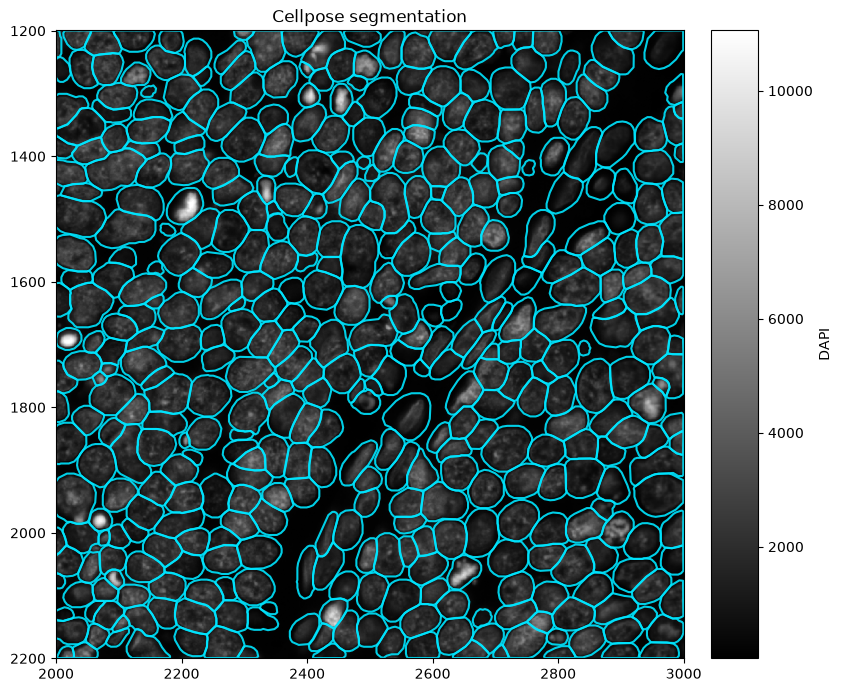

In [9]:
(
    sdata.pl.render_images("morphology_focus", channel="DAPI", cmap="gray")
    .pl.render_shapes("cellpose_boundaries", fill_alpha=0, outline_alpha=0.9, outline_color="#00e5ff")
    .pl.show(coordinate_systems="global", title="Cellpose segmentation", figsize=(7, 7))
)

> **_Question:_** Find a place where this segmentation is clearly wrong. Would a human
> annotator agree on the right answer there? What does that imply about "ground truth" for
> segmentation?

## 5. Aggregate: from boundaries back to a table

New boundaries are not yet an analysis object. `sopa.aggregate` counts the transcripts
falling inside each new polygon and builds the `AnnData` table — which is the same operation
the instrument performed to give us the vendor table, now under our control.

`min_transcripts` drops objects that caught almost nothing; this is the same judgement call
as the count filter in Session 2.1, made earlier in the pipeline.

In [10]:
sopa.aggregate(
    sdata,
    aggregate_genes=True,
    aggregate_channels=False,
    shapes_key="cellpose_boundaries",
    min_transcripts=5,
    key_added="table_cellpose",
)

sdata["table_cellpose"]

[INFO] (sopa.aggregation.transcripts) Aggregating transcripts over 440 cells


[                                        ] | 0% Completed | 119.88 us

[########################################] | 100% Completed | 101.36 ms

[INFO] (sopa.aggregation.aggregation) 0 cell(s) not passing filtering due to transcript count < 5


AnnData object with n_obs × n_vars = 440 × 280
    obs: 'region', 'slide', 'cell_id', 'area'
    uns: 'sopa_attrs', 'spatialdata_attrs'
    obsm: 'spatial'
    layers: None (.X)

## 6. Vendor versus SOPA, on the metrics from Session 2.1

Two numbers decide this comparison: how many cells each segmentation found, and what
fraction of the transcripts each one managed to assign. Everything else is commentary.

In [11]:
vendor = sdata["table"]
cellpose = sdata["table_cellpose"]

n_transcripts = len(sdata["transcripts"])
rows = []
for name, table in [("vendor (10x)", vendor), ("SOPA + Cellpose", cellpose)]:
    counts = np.asarray(table.X.sum(axis=1)).ravel()
    rows.append(
        {
            "segmentation": name,
            "cells": table.n_obs,
            "median counts/cell": float(np.median(counts)),
            "transcripts assigned": int(counts.sum()),
            "assignment rate": counts.sum() / n_transcripts,
        }
    )

pd.DataFrame(rows).set_index("segmentation").round(3)

,cells,median counts/cell,transcripts assigned,assignment rate
segmentation,,,,
vendor (10x),455,144.0,70175,0.968
SOPA + Cellpose,440,138.0,60906,0.840


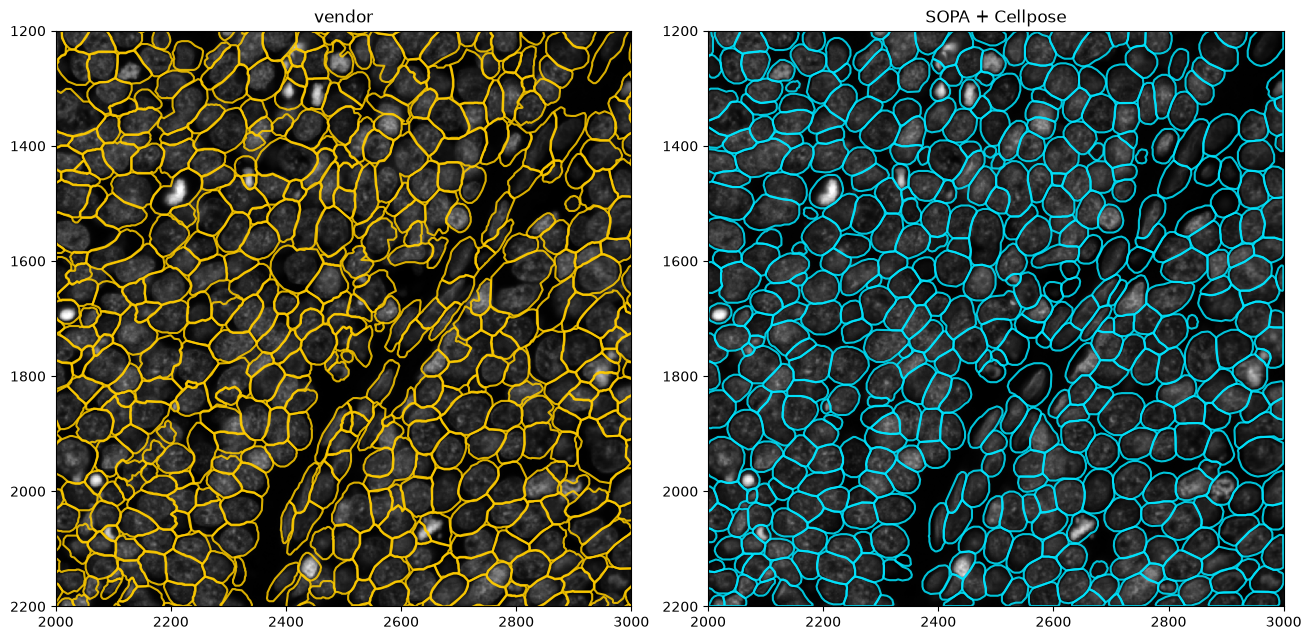

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(13, 6.5), layout="constrained")
for ax, (shapes, colour, title) in zip(
    axs, [("cell_boundaries", "#ffcc00", "vendor"), ("cellpose_boundaries", "#00e5ff", "SOPA + Cellpose")]
):
    (
        sdata.pl.render_images("morphology_focus", channel="DAPI", cmap="gray")
        .pl.render_shapes(shapes, fill_alpha=0, outline_alpha=0.85, outline_color=colour)
        .pl.show(coordinate_systems="global", ax=ax, title=title, colorbar=False)
    )
    # Boundaries of cells straddling the crop edge extend past the image; clip so both
    # panels show exactly the same field of view.
    ax.set_xlim(2000, 3000)
    ax.set_ylim(2200, 1200)
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.show()

## 7. The other backends, and when to want them

Cellpose segments an **image**. If your tissue has no usable membrane stain, or cells are
densely packed enough that their boundaries are genuinely ambiguous in the image, then
image-based segmentation is guessing — and a transcript-aware method will do better, because
it uses the actual measurement rather than a proxy for it.

| Backend | Uses | Cost | Fails when |
|---|---|---|---|
| `sopa.segmentation.cellpose` | nuclear / membrane stain | minutes on CPU | no membrane stain, dense tissue |
| `sopa.segmentation.baysor` | transcript positions | slow, external binary | low transcript density |
| `sopa.segmentation.proseg` | transcript positions | faster than Baysor | very large panels |
| `sopa.segmentation.stardist` | star-convex nuclei | fast | irregular shapes |
| `sopa.segmentation.comseg` | transcripts + prior nuclei | moderate | poor nuclear detection |

Baysor and Proseg need `sopa.make_transcript_patches` rather than `make_image_patches`, and
external binaries that are not installed here. **Pre-run them and distribute the output** —
that is what we would do for a real course dataset, and what you should do for a real slide.

### Exercise

1. Re-run §4 with `diameter=20` and again with `diameter=50`, saving each to a different
   `key_added`. Record cell count, median counts per cell, and assignment rate for each.
2. Plot all three segmentations over the same DAPI crop.
3. Which diameter is "best"? Defend it with a number, not an impression.
4. Compute the nucleus:cell ratio for the Cellpose boundaries. How does it compare to the
   vendor's, and what does that tell you about what Cellpose segmented?

> **_Question:_** The vendor segmentation assigned a far higher share of the transcripts
> than ours did, on the same patch. Does that settle which segmentation is better?

In [13]:
# your answer here

## Pitfalls

- **Do not run whole-slide segmentation live on a shared machine.** One person doing this
  slows down everyone on the box.
- **`model_type="cyto3"` requires `cellpose<4`.** On v4 the argument is accepted and quietly
  ignored, giving you a different model than the one you asked for and no error to notice.
- **`diameter` is in pixels, not micrometres.** Getting this wrong by the pixel size is the
  most common cause of "Cellpose found nothing".
- **Patch overlap exists for a reason.** With `patch_overlap=0` every cell straddling a tile
  border is cut in two, and you will see it as a grid pattern in your QC maps.
- **More cells is not better.** It is only better if those cells are real, which is what §6
  and the exercise are for.

## Further reading

- [SOPA documentation](https://gustaveroussy.github.io/sopa/) — the API reference is short
  and worth reading end to end
- [Blampey et al. (2024), *SOPA: a technology-invariant pipeline for analyses of image-based
  spatial omics*](https://www.nature.com/articles/s41467-024-48981-z)
- [Cellpose documentation](https://cellpose.readthedocs.io/en/latest/)
- [Petukhov et al. (2022), *Cell segmentation in imaging-based spatial transcriptomics*](https://www.nature.com/articles/s41587-021-01044-w) — the Baysor paper